In [1]:
%matplotlib inline
import torch
from cheetah import ParameterBeam, ParticleBeam, Segment
from impactx import ImpactX, distribution, elements, twiss
from scipy.constants import m_e, e, c
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob

In [2]:
from htu_lattice import get_lattice

# Set Initial Beam Parameters

In [3]:
# Beam energy, bunch charge, and relativistic factors
total_energy_eV = 100.0e6  # reference energy in eV (total)
mass_eV = (m_e*c**2)/e  # particle mass
kin_energy_eV = total_energy_eV - mass_eV
bunch_charge_C = 25.0e-12  # used with space charge
npart = 100000  # number of macro particles
gamma = total_energy_eV/mass_eV
bg = np.sqrt(gamma**2-1.0).item()

In [4]:
# Twiss functions and initial beam moments
beta_x = 0.002  #in m
alpha_x = 0.0
emittance_x = 1.5e-6/bg  #in m.rad
beta_y = 0.002  #in m
alpha_y = 0.0
emittance_y = 1.5e-6/bg  #in m.rad
sigma_tau = 1e-6  #in m
sigma_p = 2.5e-2  #dimensionless
mu_p = 1.0e-2  #dimensionless - relative momentum offset

# Simulation using ImpactX

In [5]:
from impactx import ImpactX, distribution, elements, twiss

In [6]:
sim = ImpactX() 

# set numerical parameters and IO control
sim.particle_shape = 2  # B-spline order
sim.space_charge = False
sim.slice_step_diagnostics = True

# silent running
silent = True
if silent:
    sim.verbose = 0
    sim.tiny_profiler = False
    # note: lattice beam monitors will still write files
    sim.diagnostics = False

# domain decomposition & space charge mesh
sim.init_grids()

In [7]:
# set reference particle
ref = sim.particle_container().ref_particle()
ref.set_charge_qe(-1.0).set_mass_MeV(mass_eV*1e-6).set_kin_energy_MeV(kin_energy_eV*1e-6)

In [8]:
#   particle bunch
distr = distribution.Gaussian(
    **twiss(
        beta_x=beta_x,
        beta_y=beta_y,
        beta_t=sigma_tau/sigma_p,
        emitt_x=emittance_x,
        emitt_y=emittance_y,
        emitt_t=sigma_tau*sigma_p,
        alpha_x=alpha_x,
        alpha_y=alpha_y,
        alpha_t=0.0,
    ),
    meanPt=-mu_p,
)
sim.add_particles(bunch_charge_C, distr, npart)

# record purely in memory
sim.particle_container().enable_beam_history = True

In [9]:
# set the lattice
sim.lattice.extend( get_lattice("impactx") )

# run simulation  
sim.track_particles()

In [10]:
# store the beam particle container and reduced beam diagnostics (history)
beam = sim.particle_container()
beam_history = sim.particle_container().beam_history()

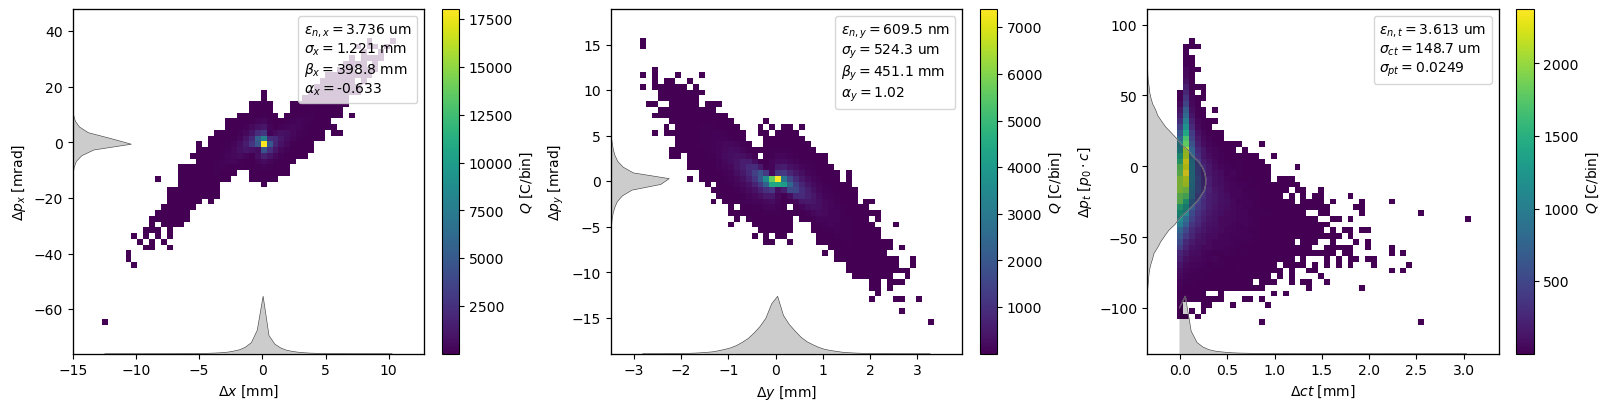

In [12]:
# plot the beam phase space at the exit of the system
fig = beam.plot_phasespace()

# note: figure data available on MPI rank zero
if fig is not None:
    fig.savefig("phase_space.png")
    plt.show()

In [13]:
# collect the beam moment history
s = beam_history.s
sig_x_mm = beam_history.sig_x
sig_y_mm = beam_history.sig_y

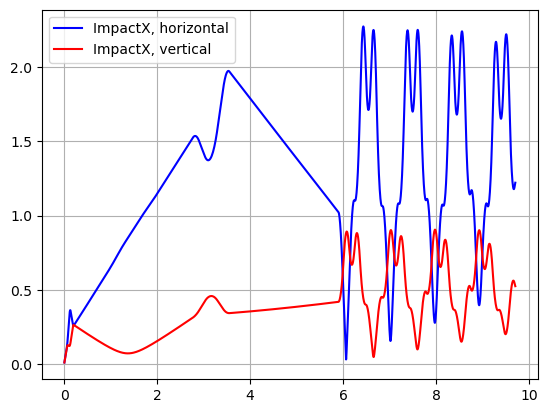

In [14]:
# Plot the ImpactX results
plt.plot( s, 1e3*sig_x_mm, 'b', label="ImpactX, horizontal" )
plt.plot( s, 1e3*sig_y_mm, 'r', label="ImpactX, vertical" )

plt.legend(loc=0)
plt.grid()

In [14]:
# clean shutdown
sim.finalize()